
# REFUGE Cup & Disc Segmentation  
(U-Net + EfficientNetB4 Encoder)



Struktur folder input:

```text
/content/drive/MyDrive/REFUGE101/BV_CDR/
└── REFUG_raw/
    ├── images/
    ├── masks_cup/
    └── masks_disc/
```

Output hasil prediksi akan disimpan ke:

```text
/content/drive/MyDrive/REFUGE101/BV_CDR/pred_mask_cup_disc_efficientnetb4/
├── pred_cup/
├── pred_disc/
├── best_model/
├── previews/
├── splits/
└── metrics/
```

Model:
- Encoder: EfficientNetB4 pretrained ImageNet
- Decoder: U-Net decoder
- Output: 2 channel mask
  - channel 0 = cup
  - channel 1 = disc


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

!pip -q install openpyxl scikit-learn


In [ ]:
import os
import glob
import random
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. Konfigurasi path dan parameter training


In [ ]:
# CONFIG
BASE_DIR = "/content/drive/MyDrive/BV_CDR"
ENCODER_TYPE = "efficientnetb4"
REFUGE_RAW_DIR = os.path.join(BASE_DIR, "REFUG_raw")
IMAGE_DIR = os.path.join(REFUGE_RAW_DIR, "images")
CUP_DIR = os.path.join(REFUGE_RAW_DIR, "masks_cup")
DISC_DIR = os.path.join(REFUGE_RAW_DIR, "masks_disc")

# output
OUT_DIR = os.path.join(BASE_DIR, f"FIX4_pred_mask_cup_disc_{ENCODER_TYPE}")
PRED_CUP_DIR = os.path.join(OUT_DIR, "pred_cup")
PRED_DISC_DIR = os.path.join(OUT_DIR, "pred_disc")
BEST_MODEL_DIR = os.path.join(OUT_DIR, "best_model")
PREVIEW_DIR = os.path.join(OUT_DIR, "previews")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
METRIC_DIR = os.path.join(OUT_DIR, "metrics")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

for p in [
    OUT_DIR,
    PRED_CUP_DIR,
    PRED_DISC_DIR,
    BEST_MODEL_DIR,
    PREVIEW_DIR,
    SPLIT_DIR,
    METRIC_DIR,
    PLOT_DIR
]:
    os.makedirs(p, exist_ok=True)


IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 60
LEARNING_RATE = 1e-4

BEST_MODEL_PATH = os.path.join(BEST_MODEL_DIR, f"best_unet_{ENCODER_TYPE}_cup_disc.keras")
LAST_MODEL_PATH = os.path.join(BEST_MODEL_DIR, f"last_unet_{ENCODER_TYPE}_cup_disc.keras")

print("ENCODER_TYPE:", ENCODER_TYPE)
print("IMAGE_DIR:", IMAGE_DIR)
print("CUP_DIR:", CUP_DIR)
print("DISC_DIR:", DISC_DIR)
print("OUT_DIR:", OUT_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)


ENCODER_TYPE: efficientnetb4
IMAGE_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/images
CUP_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/masks_cup
DISC_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/masks_disc
OUT_DIR: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4
BEST_MODEL_PATH: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/best_model/best_unet_efficientnetb4_cup_disc.keras


In [ ]:
# cek pasangan image dan mask

assert os.path.exists(IMAGE_DIR), f"Folder images tidak ditemukan: {IMAGE_DIR}"
assert os.path.exists(CUP_DIR), f"Folder masks_cup tidak ditemukan: {CUP_DIR}"
assert os.path.exists(DISC_DIR), f"Folder masks_disc tidak ditemukan: {DISC_DIR}"

def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

image_dict = {
    stem(p): p for p in glob.glob(os.path.join(IMAGE_DIR, "*"))
    if os.path.isfile(p)
}

cup_dict = {
    stem(p): p for p in glob.glob(os.path.join(CUP_DIR, "*"))
    if os.path.isfile(p)
}

disc_dict = {
    stem(p): p for p in glob.glob(os.path.join(DISC_DIR, "*"))
    if os.path.isfile(p)
}

names = sorted(list(set(image_dict.keys()) & set(cup_dict.keys()) & set(disc_dict.keys())))

missing_image = sorted(list((set(cup_dict.keys()) | set(disc_dict.keys())) - set(image_dict.keys())))
missing_cup = sorted(list(set(image_dict.keys()) - set(cup_dict.keys())))
missing_disc = sorted(list(set(image_dict.keys()) - set(disc_dict.keys())))

print("Jumlah image:", len(image_dict))
print("Jumlah cup mask:", len(cup_dict))
print("Jumlah disc mask:", len(disc_dict))
print("Jumlah pasangan lengkap:", len(names))
print("Missing image:", len(missing_image))
print("Missing cup:", len(missing_cup))
print("Missing disc:", len(missing_disc))

if len(missing_cup) > 0:
    print("Contoh missing cup:", missing_cup[:10])

if len(missing_disc) > 0:
    print("Contoh missing disc:", missing_disc[:10])

rows = []
for name in names:
    rows.append({
        "name_no_ext": name,
        "filename": os.path.basename(image_dict[name]),
        "image_path": image_dict[name],
        "cup_path": cup_dict[name],
        "disc_path": disc_dict[name]
    })

pairs_df = pd.DataFrame(rows)
pairs_csv_path = os.path.join(SPLIT_DIR, "all_pairs_cup_disc.csv")
pairs_df.to_csv(pairs_csv_path, index=False)

print("Saved all pairs:", pairs_csv_path)
pairs_df.head()


Jumlah image: 400
Jumlah cup mask: 400
Jumlah disc mask: 400
Jumlah pasangan lengkap: 400
Missing image: 0
Missing cup: 0
Missing disc: 0
Saved all pairs: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/splits/all_pairs_cup_disc.csv


,name_no_ext,filename,image_path,cup_path,disc_path
0,REFUGE1-train-1,REFUGE1-train-1.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
1,REFUGE1-train-10,REFUGE1-train-10.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
2,REFUGE1-train-100,REFUGE1-train-100.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
3,REFUGE1-train-101,REFUGE1-train-101.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
4,REFUGE1-train-102,REFUGE1-train-102.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...


In [ ]:
# split 70 train; 15 val; 15 test

train_df, temp_df = train_test_split(
    pairs_df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_path = os.path.join(SPLIT_DIR, "train_cup_disc.csv")
val_path = os.path.join(SPLIT_DIR, "val_cup_disc.csv")
test_path = os.path.join(SPLIT_DIR, "test_cup_disc.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train:", len(train_df), train_path)
print("Val:", len(val_df), val_path)
print("Test:", len(test_df), test_path)


Train: 280 /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/splits/train_cup_disc.csv
Val: 60 /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/splits/val_cup_disc.csv
Test: 60 /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/splits/test_cup_disc.csv


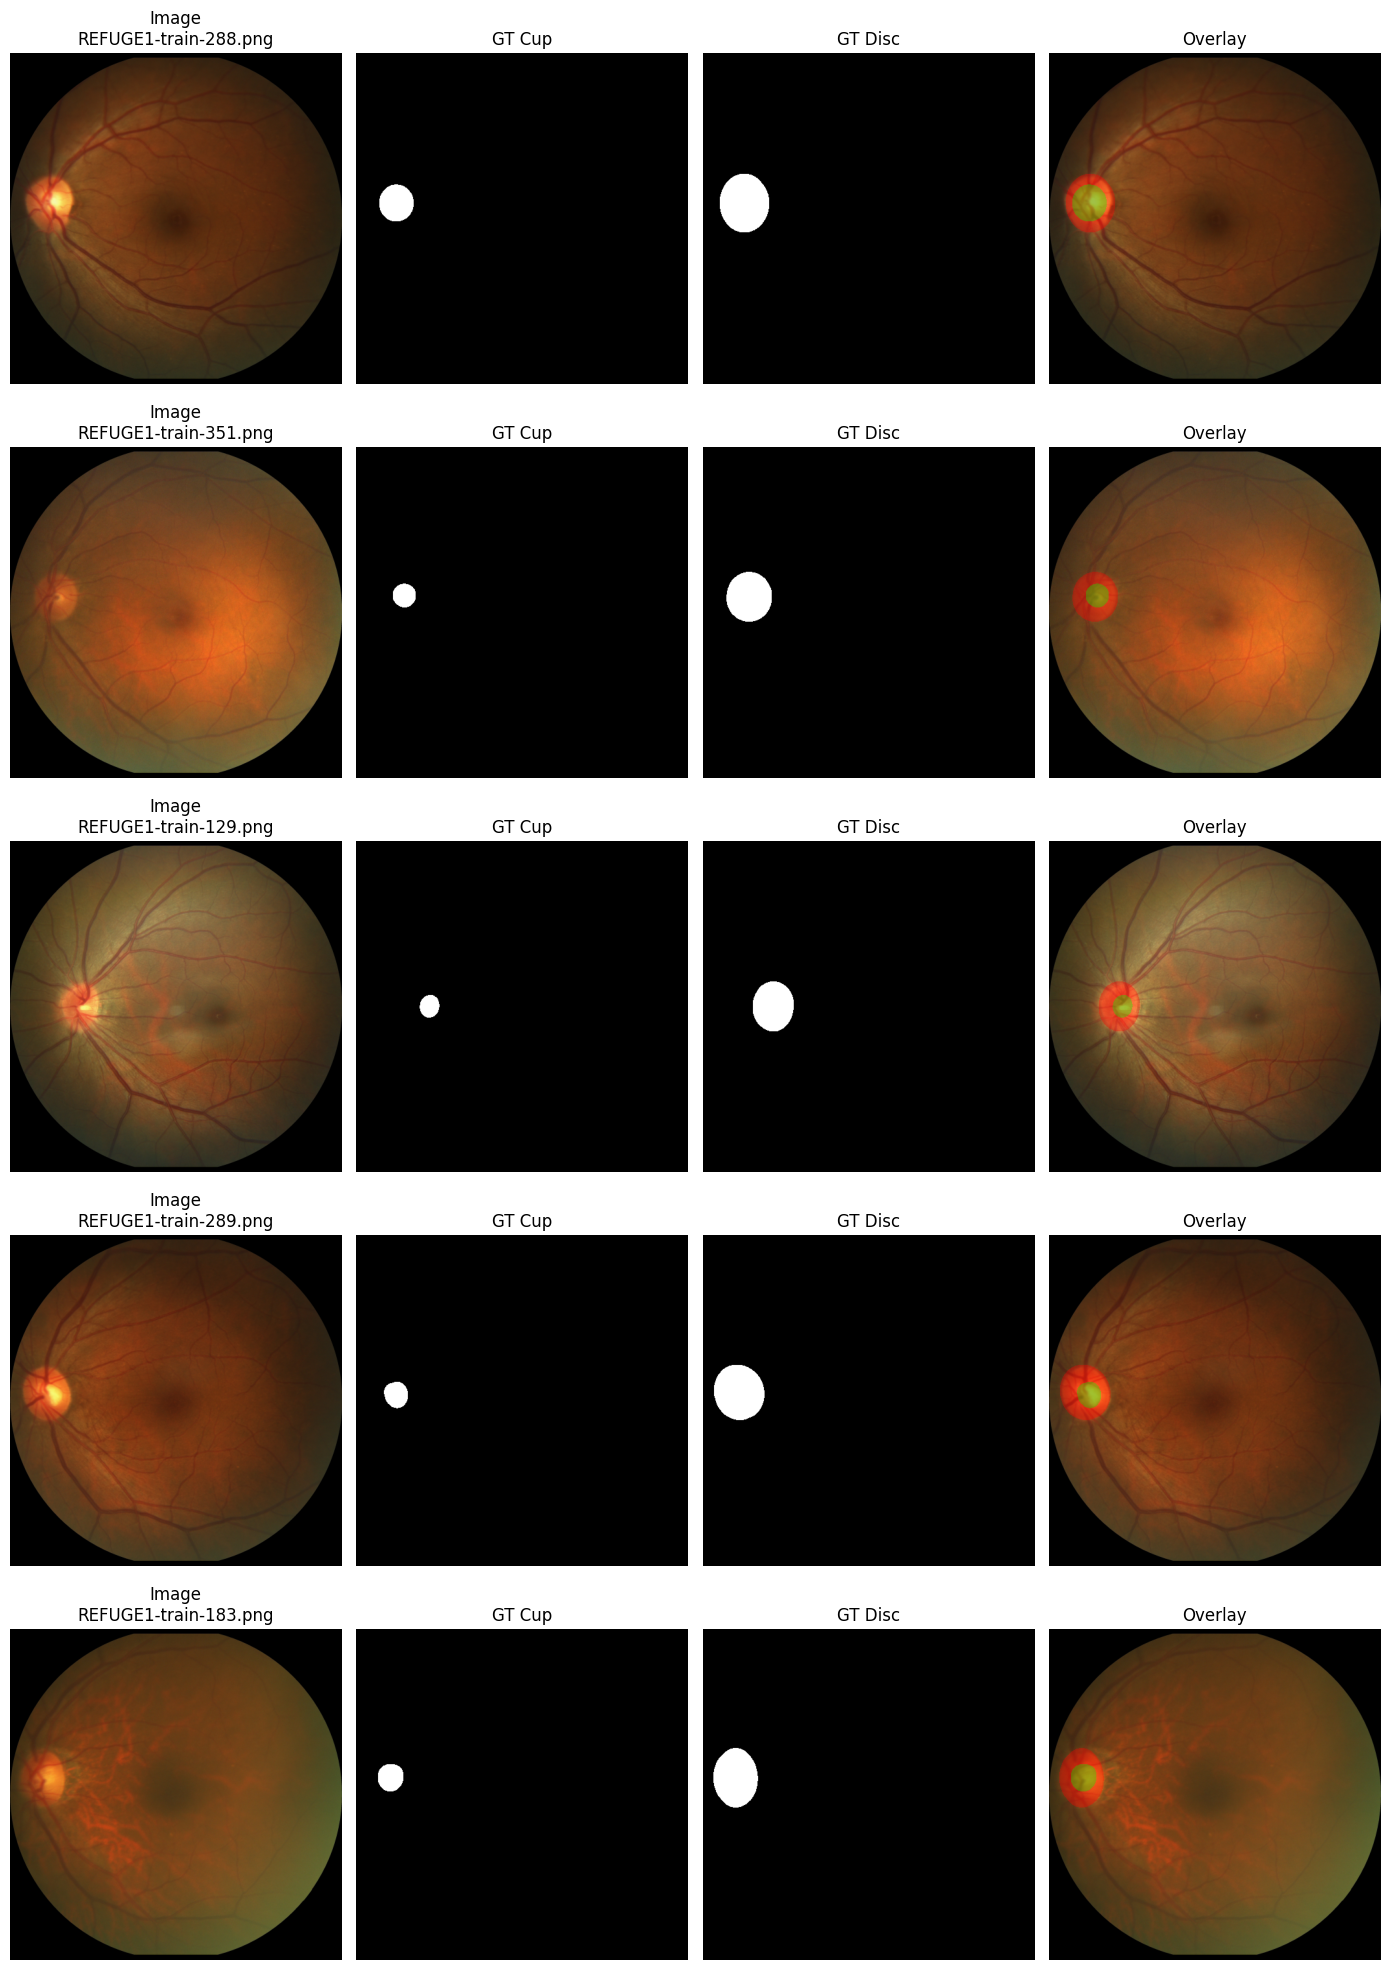

In [ ]:
# preview image dan ground truth

def read_rgb_cv(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Gagal membaca image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray_cv(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca mask: {path}")
    return img

def binarize(mask):
    return (mask > 0).astype(np.uint8)

sample_df = pairs_df.sample(n=min(5, len(pairs_df)), random_state=SEED)

plt.figure(figsize=(14, 4 * len(sample_df)))

for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    img = read_rgb_cv(row.image_path)
    cup = binarize(read_gray_cv(row.cup_path))
    disc = binarize(read_gray_cv(row.disc_path))

    overlay = img.copy()
    overlay[disc > 0] = (0.65 * overlay[disc > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay[cup > 0] = (0.65 * overlay[cup > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(sample_df), 4, (i-1)*4 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 2)
    plt.imshow(cup, cmap="gray")
    plt.title("GT Cup")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 3)
    plt.imshow(disc, cmap="gray")
    plt.title("GT Disc")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# augmentasi, 0 = cup; 1 = disc

def decode_image(path, channels=3):
    data = tf.io.read_file(path)
    img = tf.image.decode_image(data, channels=channels, expand_animations=False)
    img.set_shape([None, None, channels])
    return img

def load_sample(image_path, cup_path, disc_path):
    image = decode_image(image_path, channels=3)
    cup = decode_image(cup_path, channels=1)
    disc = decode_image(disc_path, channels=1)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    cup = tf.image.resize(cup, [IMG_SIZE, IMG_SIZE], method="nearest")
    disc = tf.image.resize(disc, [IMG_SIZE, IMG_SIZE], method="nearest")

    image = tf.cast(image, tf.float32)
    cup = tf.cast(cup > 0, tf.float32)
    disc = tf.cast(disc > 0, tf.float32)

    mask = tf.concat([cup, disc], axis=-1)
    return image, mask

def augment_sample(image, mask):
    do_flip = tf.random.uniform(()) > 0.5
    image = tf.cond(do_flip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    image = tf.image.random_brightness(image, max_delta=8.0)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 255.0)

    return image, mask

def make_dataset(df, batch_size=4, training=False):
    image_paths = df["image_path"].values
    cup_paths = df["cup_path"].values
    disc_paths = df["disc_path"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, cup_paths, disc_paths))
    ds = ds.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, BATCH_SIZE, training=True)
val_ds = make_dataset(val_df, BATCH_SIZE, training=False)
test_ds = make_dataset(test_df, BATCH_SIZE, training=False)

for img_batch, mask_batch in train_ds.take(1):
    print("Image batch:", img_batch.shape, img_batch.dtype, tf.reduce_min(img_batch).numpy(), tf.reduce_max(img_batch).numpy())
    print("Mask batch:", mask_batch.shape, mask_batch.dtype, tf.reduce_min(mask_batch).numpy(), tf.reduce_max(mask_batch).numpy())


Image batch: (2, 512, 512, 3) <dtype: 'float32'> 0.0 255.0
Mask batch: (2, 512, 512, 2) <dtype: 'float32'> 0.0 1.0


In [ ]:
# loss = bce + dice loss

SMOOTH = 1e-6

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)

def iou_coef(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + SMOOTH) / (union + SMOOTH)

def dice_cup(y_true, y_pred):
    return dice_coef(y_true[..., 0:1], y_pred[..., 0:1])

def dice_disc(y_true, y_pred):
    return dice_coef(y_true[..., 1:2], y_pred[..., 1:2])

def iou_cup(y_true, y_pred):
    return iou_coef(y_true[..., 0:1], y_pred[..., 0:1])

def iou_disc(y_true, y_pred):
    return iou_coef(y_true[..., 1:2], y_pred[..., 1:2])


In [ ]:
# model unet + efnetb4

def conv_block(x, filters, name):
    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    return x


def decoder_block(x, skip, filters, name):
    x = layers.UpSampling2D(
        (2, 2),
        interpolation="bilinear",
        name=f"{name}_upsample"
    )(x)

    if skip is not None:
        x = layers.Concatenate(name=f"{name}_concat")([x, skip])

    x = conv_block(x, filters, name=f"{name}_convblock")
    return x


def build_unet_efficientnetb4(input_shape=(512, 512, 3), num_classes=2):
    inputs = keras.Input(shape=input_shape, name="image_input")


    encoder = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    s1 = encoder.get_layer("block1b_add").output
    s2 = encoder.get_layer("block2d_add").output
    s3 = encoder.get_layer("block3d_add").output
    s4 = encoder.get_layer("block4f_add").output
    b1 = encoder.get_layer("top_activation").output

    d1 = decoder_block(b1, s4, 512, "decoder1")
    d2 = decoder_block(d1, s3, 256, "decoder2")
    d3 = decoder_block(d2, s2, 128, "decoder3")
    d4 = decoder_block(d3, s1, 64, "decoder4")
    d5 = decoder_block(d4, None, 32, "decoder5")

    outputs = layers.Conv2D(
        num_classes,
        kernel_size=1,
        padding="same",
        activation="sigmoid",
        name="cup_disc_output"
    )(d5)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="UNet_EfficientNetB4_CupDisc"
    )
    return model


model = build_unet_efficientnetb4(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=2
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        dice_cup,
        dice_disc,
        iou_coef,
        iou_cup,
        iou_disc
    ]
)

model.summary()


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "UNet_EfficientNetB4_CupDisc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 512, 512,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 512, 512,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 512, 512,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 513, 513,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 256, 256,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 256, 256,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 256, 256,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 256, 256,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 256, 256,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 256, 256,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 256, 256,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 256, 256,  │      1,152 │ block1a_se_excit

 Total params: 31,346,529 (119.58 MB)

 Trainable params: 31,217,354 (119.08 MB)

 Non-trainable params: 129,175 (504.59 KB)

In [ ]:
# training model

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

model.save(LAST_MODEL_PATH)
print("Best model saved:", BEST_MODEL_PATH)
print("Last model saved:", LAST_MODEL_PATH)


Epoch 1/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - dice_coef: 0.0529 - dice_cup: 0.0245 - dice_disc: 0.0740 - iou_coef: 0.2680 - iou_cup: 0.2307 - iou_disc: 0.2809 - loss: 1.4221
Epoch 1: val_dice_coef improved from None to 0.03931, saving model to /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/best_model/best_unet_efficientnetb4_cup_disc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/best_model/best_unet_efficientnetb4_cup_disc.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 305s 642ms/step - dice_coef: 0.0642 - dice_cup: 0.0311 - dice_disc: 0.0884 - iou_coef: 0.5141 - iou_cup: 0.4353 - iou_disc: 0.5406 - loss: 1.3201 - val_dice_coef: 0.0393 - val_dice_cup: 0.0210 - val_dice_disc: 0.0506 - val_iou_coef: 0.0254 - val_iou_cup: 0.0211 - val_iou_disc: 0.0269 - val_loss: 2.0258 - learning_rate: 1.0000e-04
Epoch 2/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - dice_coef: 0.0816 - dice_cup: 0.0410 - dice_disc: 0.10

History saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/metrics/training_history_unet_efficientnetb4_cup_disc.csv


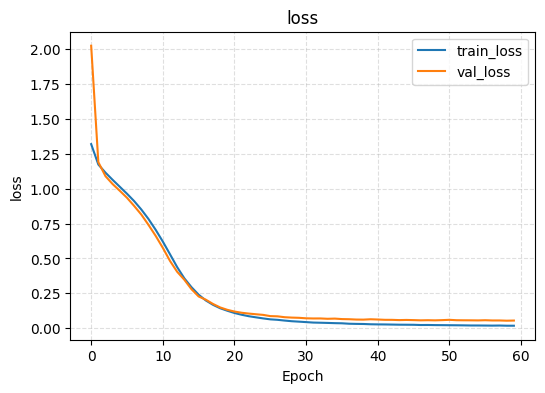

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/loss.png


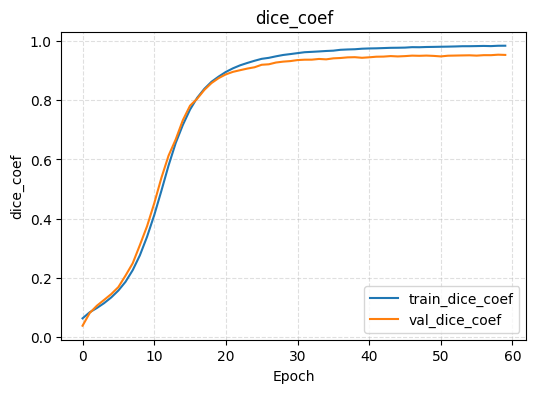

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/dice_coef.png


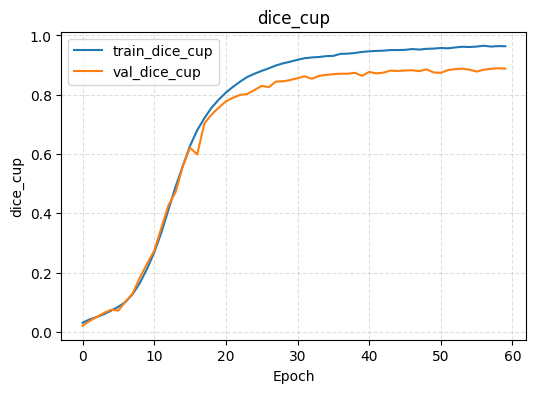

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/dice_cup.png


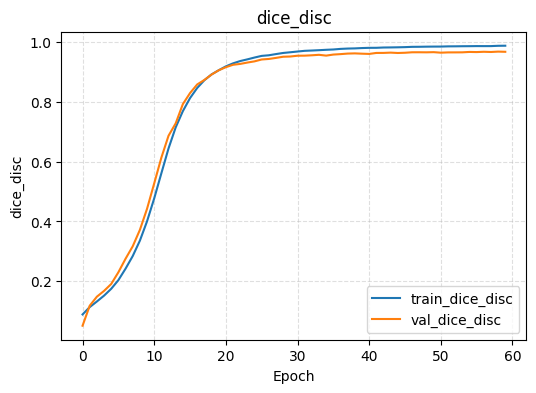

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/dice_disc.png


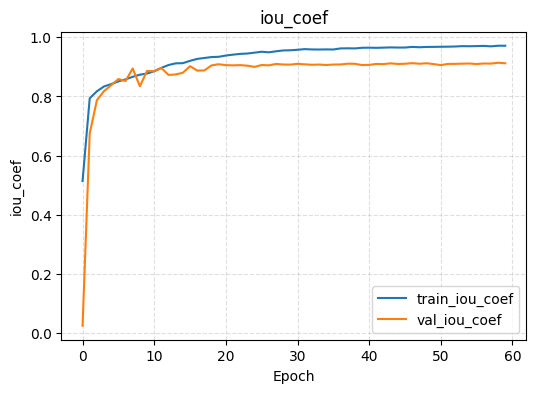

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/iou_coef.png


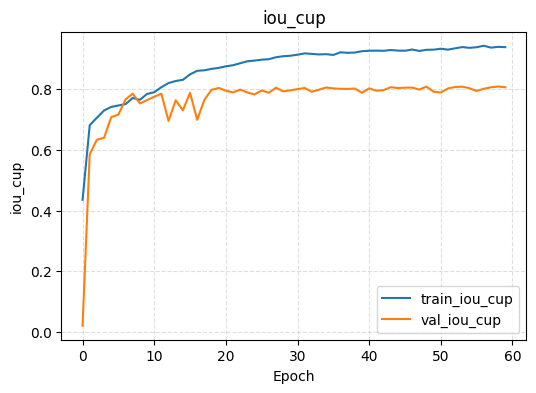

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/iou_cup.png


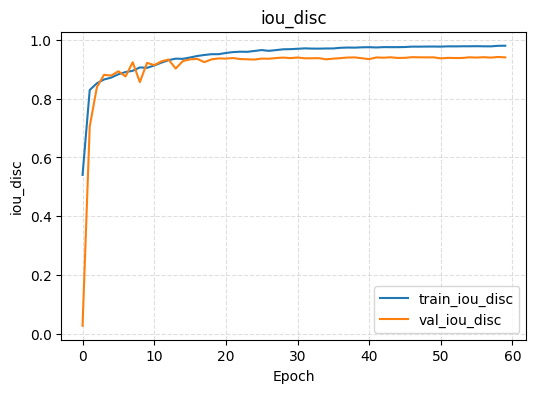

Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/plots/iou_disc.png


In [ ]:
# plot train history

hist_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(METRIC_DIR, f"training_history_unet_{ENCODER_TYPE}_cup_disc.csv")
hist_df.to_csv(history_csv_path, index=False)
print("History saved:", history_csv_path)

metrics_to_plot = [
    "loss",
    "dice_coef",
    "dice_cup",
    "dice_disc",
    "iou_coef",
    "iou_cup",
    "iou_disc"
]

for m in metrics_to_plot:
    if m in hist_df.columns and f"val_{m}" in hist_df.columns:
        plt.figure(figsize=(6, 4))
        plt.plot(hist_df[m], label=f"train_{m}")
        plt.plot(hist_df[f"val_{m}"], label=f"val_{m}")
        plt.title(m)
        plt.xlabel("Epoch")
        plt.ylabel(m)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.4)
        save_path = os.path.join(PLOT_DIR, f"{m}.png")
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", save_path)



In [ ]:
#evaluasi test set

best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "dice_cup": dice_cup,
        "dice_disc": dice_disc,
        "iou_coef": iou_coef,
        "iou_cup": iou_cup,
        "iou_disc": iou_disc
    }
)

test_result = best_model.evaluate(test_ds, verbose=1)

# Pada beberapa versi Keras, metrics_names dapat terbaca sebagai compile_metrics.
# Karena itu nama metrik dibuat manual agar file JSON lengkap.
metric_names = [
    "loss",
    "dice_coef",
    "dice_cup",
    "dice_disc",
    "iou_coef",
    "iou_cup",
    "iou_disc"
]

test_metrics = dict(zip(metric_names, test_result))

test_metrics_path = os.path.join(METRIC_DIR, f"test_metrics_unet_{ENCODER_TYPE}_cup_disc.json")
with open(test_metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=4)

print("Test metrics:")
print(json.dumps({k: float(v) for k, v in test_metrics.items()}, indent=4))
print("Saved:", test_metrics_path)


30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 642ms/step - dice_coef: 0.9467 - dice_cup: 0.8784 - dice_disc: 0.9649 - iou_coef: 0.9017 - iou_cup: 0.7897 - iou_disc: 0.9346 - loss: 0.0622
Test metrics:
{
    "loss": 0.06224046275019646,
    "dice_coef": 0.9466636776924133,
    "dice_cup": 0.8783859014511108,
    "dice_disc": 0.9649099111557007,
    "iou_coef": 0.9016658067703247,
    "iou_cup": 0.7896946668624878,
    "iou_disc": 0.9345581531524658
}
Saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/metrics/test_metrics_unet_efficientnetb4_cup_disc.json


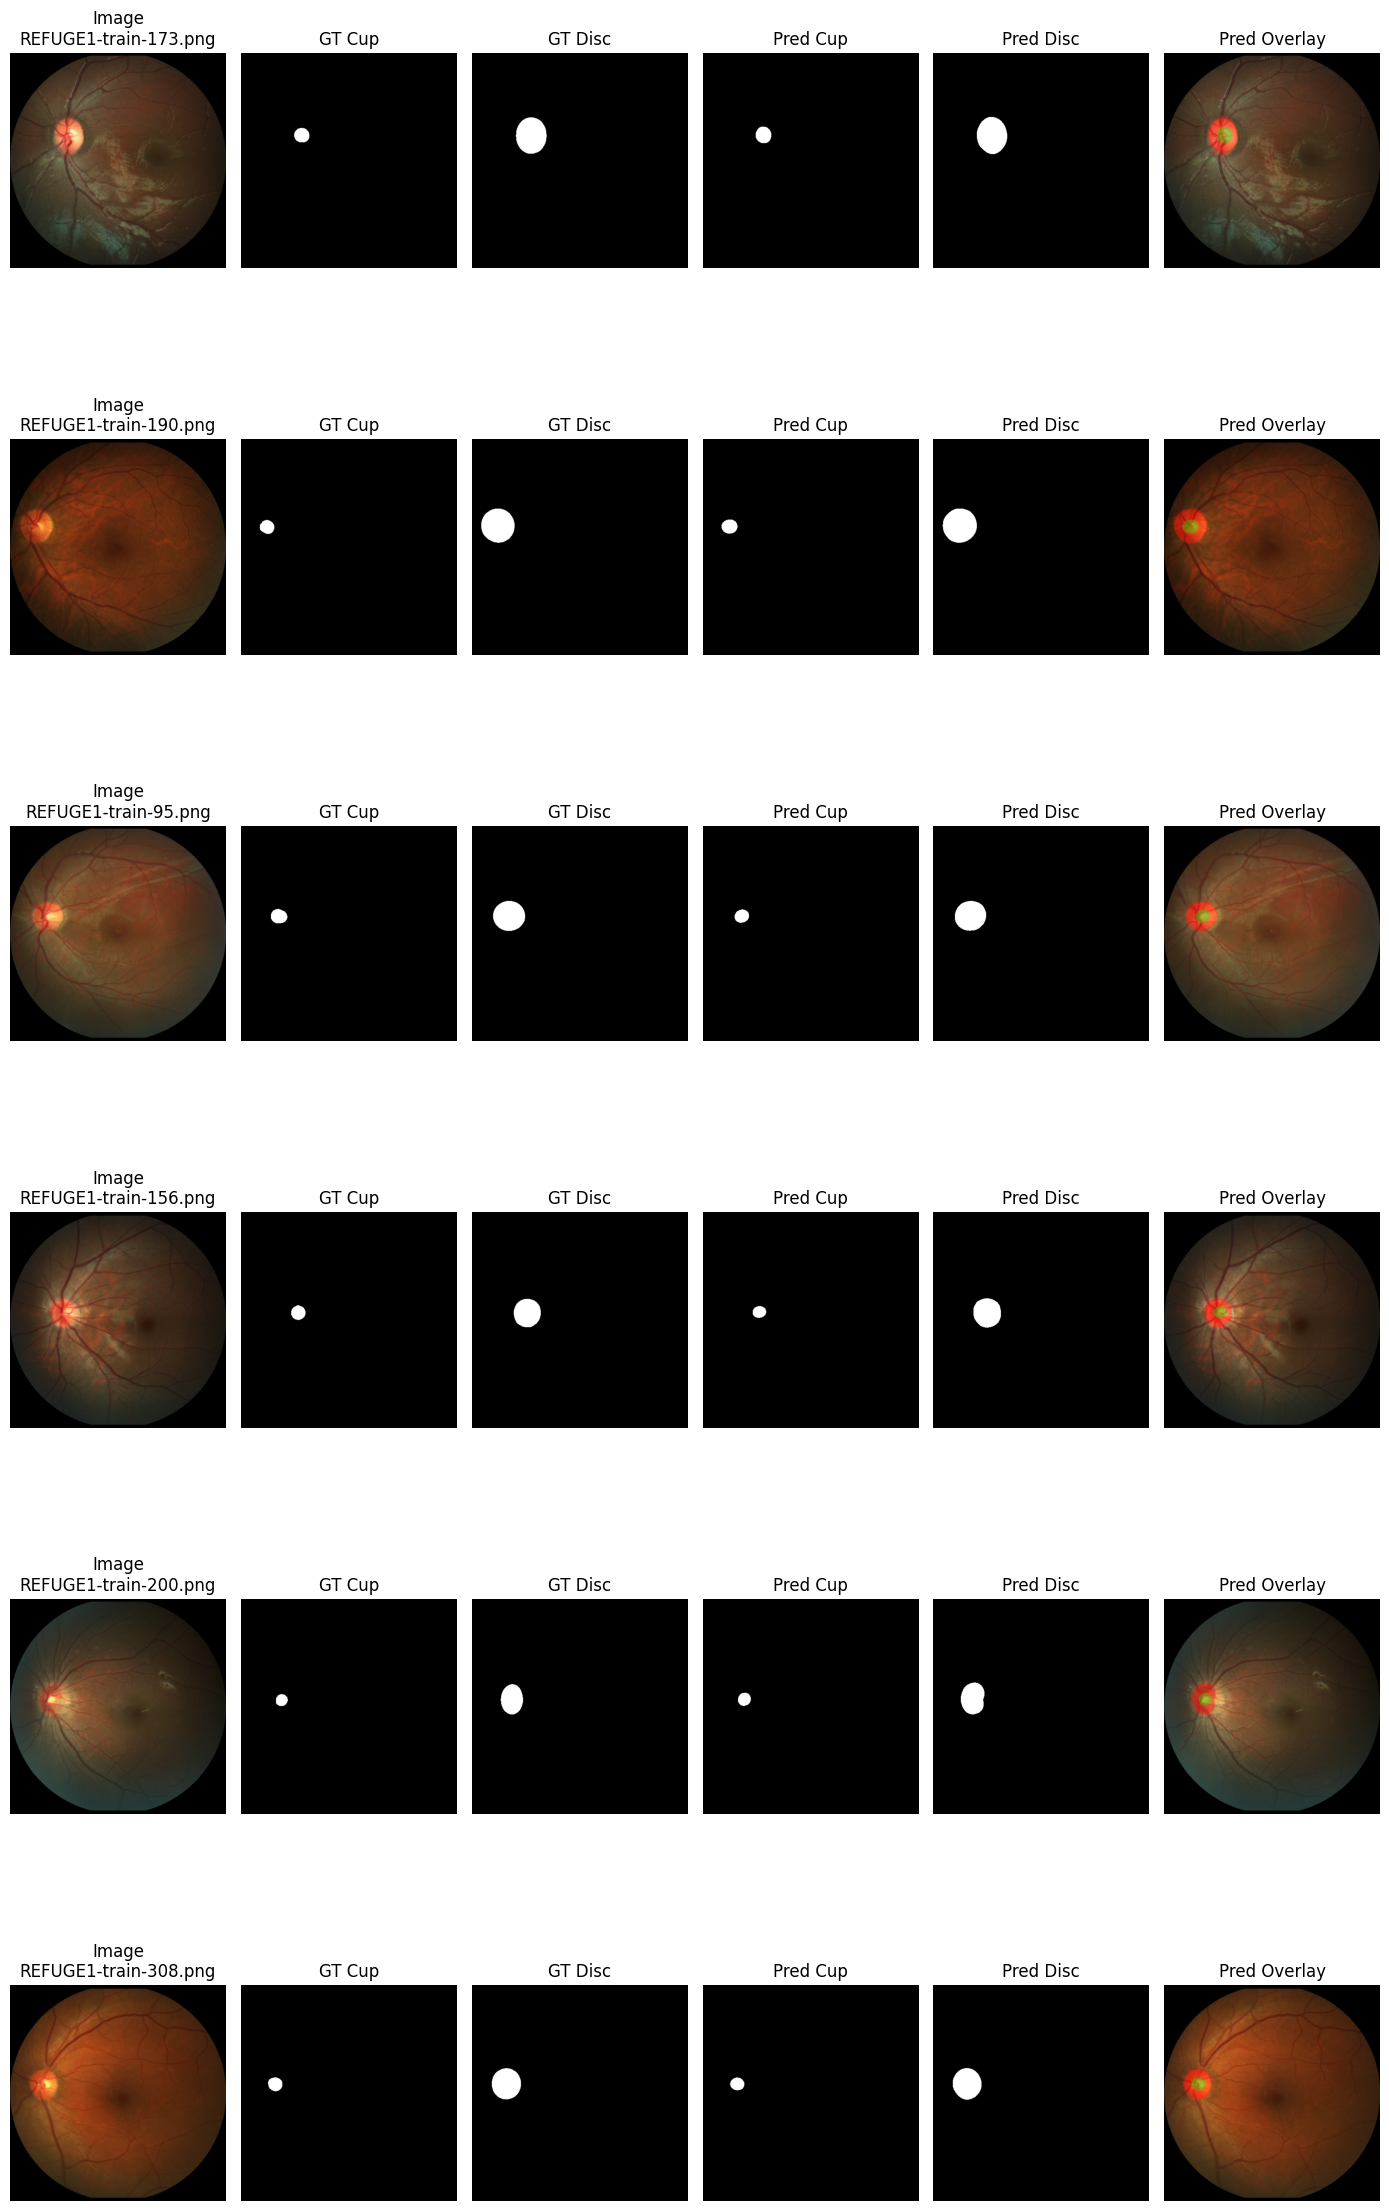

Preview saved: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/previews/test_prediction_preview.png


In [ ]:
# preview test prediction

def predict_single_image(model, image_path, img_size=512, threshold=0.5):
    image_rgb = read_rgb_cv(image_path)
    original_h, original_w = image_rgb.shape[:2]

    resized = cv2.resize(image_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    input_arr = resized.astype(np.float32)[None, ...]

    pred = model.predict(input_arr, verbose=0)[0]
    cup_pred = (pred[..., 0] >= threshold).astype(np.uint8)
    disc_pred = (pred[..., 1] >= threshold).astype(np.uint8)

    cup_pred_orig = cv2.resize(cup_pred, (original_w, original_h), interpolation=cv2.INTER_NEAREST)
    disc_pred_orig = cv2.resize(disc_pred, (original_w, original_h), interpolation=cv2.INTER_NEAREST)

    return image_rgb, cup_pred_orig, disc_pred_orig

sample_test = test_df.sample(n=min(6, len(test_df)), random_state=SEED)

plt.figure(figsize=(14, 4 * len(sample_test)))

for i, row in enumerate(sample_test.itertuples(index=False), start=1):
    img, cup_pred, disc_pred = predict_single_image(best_model, row.image_path, IMG_SIZE, threshold=0.5)

    gt_cup = binarize(read_gray_cv(row.cup_path))
    gt_disc = binarize(read_gray_cv(row.disc_path))

    overlay_pred = img.copy()
    overlay_pred[disc_pred > 0] = (0.65 * overlay_pred[disc_pred > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay_pred[cup_pred > 0] = (0.65 * overlay_pred[cup_pred > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(sample_test), 6, (i-1)*6 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 2)
    plt.imshow(gt_cup, cmap="gray")
    plt.title("GT Cup")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 3)
    plt.imshow(gt_disc, cmap="gray")
    plt.title("GT Disc")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 4)
    plt.imshow(cup_pred, cmap="gray")
    plt.title("Pred Cup")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 5)
    plt.imshow(disc_pred, cmap="gray")
    plt.title("Pred Disc")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 6)
    plt.imshow(overlay_pred)
    plt.title("Pred Overlay")
    plt.axis("off")

plt.tight_layout()
preview_path = os.path.join(PREVIEW_DIR, "test_prediction_preview.png")
plt.savefig(preview_path, dpi=200, bbox_inches="tight")
plt.show()
print("Preview saved:", preview_path)

In [ ]:
# prediksi refuge dan simpan mask cup-disc

prediction_rows = []

for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df), desc="Predicting all REFUGE cup-disc masks"):
    img, cup_pred, disc_pred = predict_single_image(best_model, row.image_path, IMG_SIZE, threshold=0.5)

    cup_save = (cup_pred * 255).astype(np.uint8)
    disc_save = (disc_pred * 255).astype(np.uint8)

    cup_save_path = os.path.join(PRED_CUP_DIR, f"{row.name_no_ext}.png")
    disc_save_path = os.path.join(PRED_DISC_DIR, f"{row.name_no_ext}.png")

    cv2.imwrite(cup_save_path, cup_save)
    cv2.imwrite(disc_save_path, disc_save)

    prediction_rows.append({
        "name_no_ext": row.name_no_ext,
        "filename": row.filename,
        "image_path": row.image_path,
        "pred_cup_path": cup_save_path,
        "pred_disc_path": disc_save_path
    })

pred_df = pd.DataFrame(prediction_rows)
pred_csv_path = os.path.join(OUT_DIR, "predicted_cup_disc_paths.csv")
pred_df.to_csv(pred_csv_path, index=False)

print("Predicted masks saved:")
print("Cup :", PRED_CUP_DIR)
print("Disc:", PRED_DISC_DIR)
print("CSV :", pred_csv_path)
pred_df.head()


In [ ]:
# preview all data

preview_df = pred_df.sample(n=min(8, len(pred_df)), random_state=123)

plt.figure(figsize=(14, 4 * len(preview_df)))

for i, row in enumerate(preview_df.itertuples(index=False), start=1):
    img = read_rgb_cv(row.image_path)
    cup_pred = binarize(read_gray_cv(row.pred_cup_path))
    disc_pred = binarize(read_gray_cv(row.pred_disc_path))

    overlay = img.copy()
    overlay[disc_pred > 0] = (0.65 * overlay[disc_pred > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay[cup_pred > 0] = (0.65 * overlay[cup_pred > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(preview_df), 4, (i-1)*4 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 2)
    plt.imshow(cup_pred, cmap="gray")
    plt.title("Pred Cup")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 3)
    plt.imshow(disc_pred, cmap="gray")
    plt.title("Pred Disc")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 4)
    plt.imshow(overlay)
    plt.title("Pred Overlay")
    plt.axis("off")

plt.tight_layout()
preview_all_path = os.path.join(PREVIEW_DIR, "all_prediction_preview.png")
plt.savefig(preview_all_path, dpi=200, bbox_inches="tight")
plt.show()

print("Preview saved:", preview_all_path)


output file:

```text
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_cup/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_disc/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/best_model/best_unet_vgg16_cup_disc.keras
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/metrics/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/previews/
```

